In [1]:
pip install vizdataquality

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: C:\Users\tomkn\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import datetime

from vizdataquality import calculate as vdqc, datasets as vdqd, plot as vdqp, report as vdqr

In [3]:
df1 = pd.read_csv('data/intermediate/time_series_model_data_prep.csv')[["player_id", "name", "year", "date_of_birth", "market_value_in_million_eur", "age", "position", "sub_position", "contract_years_left", "name_team", "team_ppg", "team_goal_difference", "total_minutes", "goals"]]

C:\Users\tomkn\AppData\Local\Temp\ipykernel_20844\4233603331.py:1: DtypeWarning: Columns (3,6,7,9,30,36) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv('data/intermediate/time_series_model_data_prep.csv')[["player_id", "name", "year", "date_of_birth", "market_value_in_million_eur", "age", "position", "sub_position", "contract_years_left", "name_team", "team_ppg", "team_goal_difference", "total_minutes", "goals"]]


In [4]:
df1 = df1.drop(columns=["player_id"])

In [5]:

num_rows = df1.shape[0]
num_cols = df1.shape[1]
print('num_rows =', num_rows, 'num_cols =', num_cols)

num_rows = 16755 num_cols = 13


In [6]:
df_output1 = vdqc.calc(df1)

In [7]:
df_output1

,Data type,Example value,Number of values,Number of zero values,Number of missing values,Number of unique values,Value lengths,Character patterns,Numeric percentiles,Datetime percentiles,Uniqueness,Data type conflict
_column,,,,,,,,,,,,
name,object,Danny Ward,16755,0,0,1826,"4,25",a0.-',,,Other,OK
year,int64,2023,16755,0,0,29,"4,4",,"2004.0,2014.0,2019.0,2022.0,2032.0",,Other,OK
date_of_birth,object,1989-09-26 00:00:00,14246,0,2509,1639,"19,19",0-:,,,Other,OK
market_value_in_million_eur,float64,1.0,16755,0,0,480,"3,18",,"0.002373046875,0.421875,1.5,5.2,180.0",,Other,OK
age,int64,22,16755,0,0,28,"2,2",,"16.0,22.0,26.0,32.0,43.0",,Other,OK
position,object,Defender,14246,0,2509,4,"6,10",a,,,Other,OK
sub_position,object,Centre-Back,14246,0,2509,13,"9,18",a-,,,Other,OK
contract_years_left,float64,0.0,14246,5650,2509,31,"3,3",,"0.0,0.0,3.0,6.0,6.0",,Other,OK
name_team,object,West Ham United Football Club,8170,0,8585,37,"9,38",a,,,Other,OK


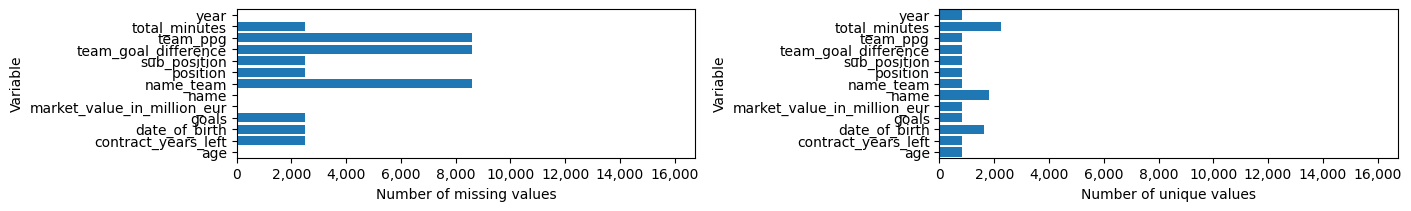

In [8]:
fig_kw = {'size_inches': (14, 2), 'constrained_layout': True}
ax_kw = {'xlim': (0, num_rows)}
columns = ['Number of missing values', 'Number of unique values']
vdqp.plotgrid('scalars', df_output1[columns].sort_index(), vert=False, fig_kw=fig_kw, ax_kw=ax_kw)

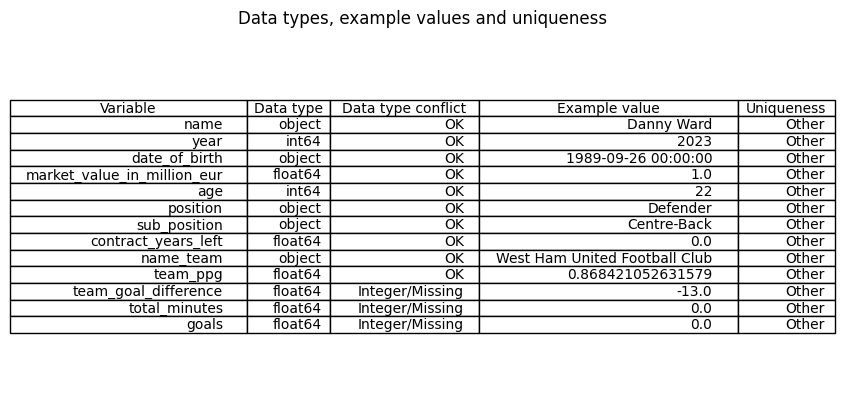

In [9]:
cols = ['Data type', 'Data type conflict', 'Example value', 'Uniqueness']
fig_kw = {}#'size_inches': (4, 2)}
ax_kw = {'title': 'Data types, example values and uniqueness'}
#, bbox_inches="tight"
vdqp.table(df_output1[cols], include_index=True, fig_kw=fig_kw, ax_kw=ax_kw, loc='center')

In [10]:
df2 = df1[df1.columns[:-1]]
df_output2 = vdqc.calc(df2)
num_rows = df2.shape[0]
num_cols = df2.shape[1]
print('num_rows =', num_rows, 'num_cols =', num_cols)

num_rows = 16755 num_cols = 12


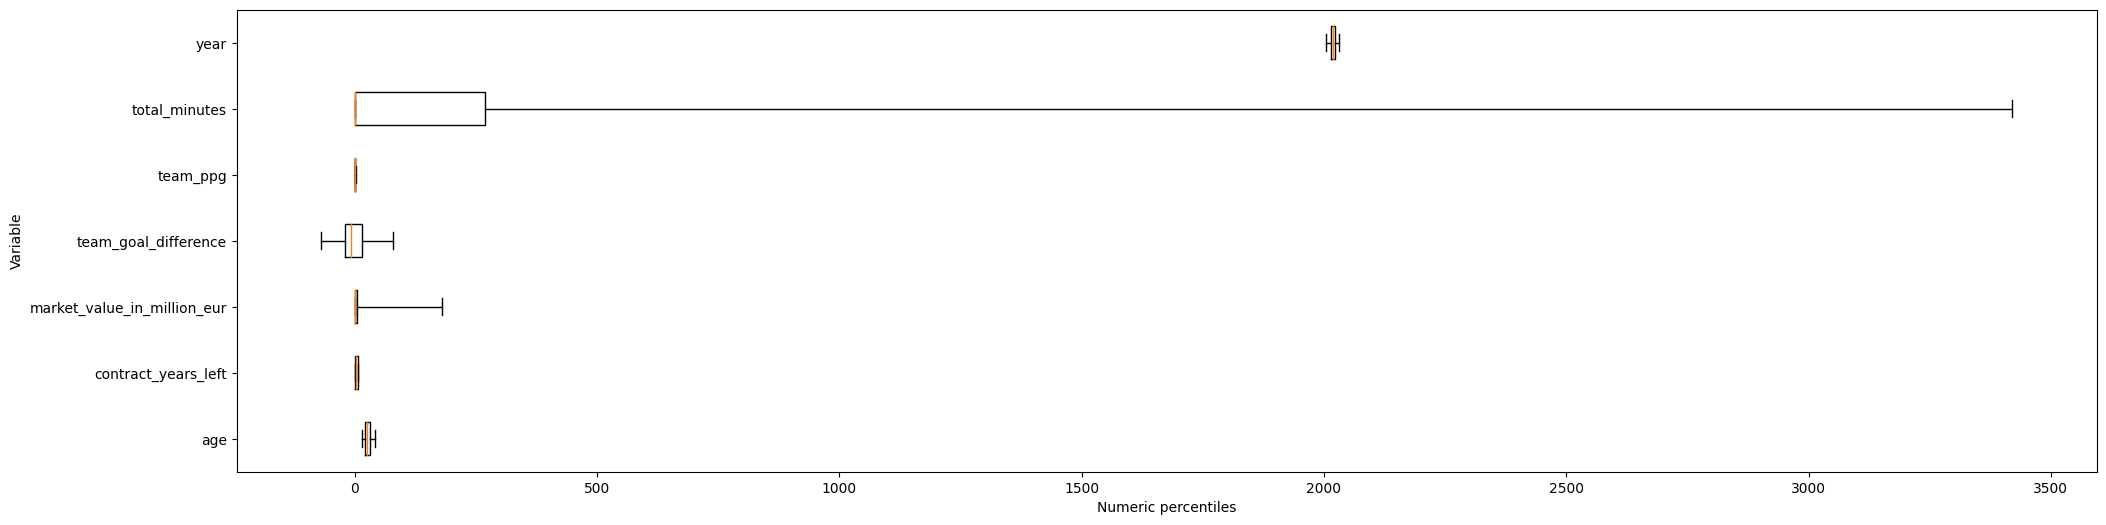

In [11]:
# Select all the numerical variables
dfo = df_output2.loc[df_output2['Data type'].isin(['int64','float64'])]

# Plot all the variables
fig_kw = {'size_inches': (24, 6)}
vdqp.boxplot(dfo['Numeric percentiles'].sort_index(), vert=False, fig_kw=fig_kw)

In [12]:
# Investigate the unusual values
col = 'total_minutes'
dftmp = df2[df2[col] > 2000]
print(col)
print('number of high values =', len(dftmp))
print('Unique values', dftmp[col].unique().tolist())

col = 'market_value_in_million_eur'
dftmp = df2[df2[col] > 80]
print(col)
print('number of high values =', len(dftmp))
print('Unique values', dftmp[col].unique().tolist())

total_minutes
number of high values = 1502
Unique values [3150.0, 2929.0, 3222.0, 2900.0, 2236.0, 3060.0, 3420.0, 2530.0, 2323.0, 2337.0, 2400.0, 2849.0, 2827.0, 2836.0, 2113.0, 2351.0, 2250.0, 3310.0, 2240.0, 2423.0, 2019.0, 2448.0, 2876.0, 2410.0, 2287.0, 2416.0, 3159.0, 2837.0, 2925.0, 3240.0, 2065.0, 2993.0, 2922.0, 3271.0, 2008.0, 2160.0, 3375.0, 3235.0, 2222.0, 2380.0, 3182.0, 2173.0, 2661.0, 2318.0, 2085.0, 2070.0, 3043.0, 2413.0, 3227.0, 2520.0, 2186.0, 2987.0, 2694.0, 2195.0, 2510.0, 3314.0, 2212.0, 2484.0, 2869.0, 2333.0, 2643.0, 3263.0, 2835.0, 3064.0, 3195.0, 3098.0, 3040.0, 2405.0, 2293.0, 2710.0, 3103.0, 3028.0, 2049.0, 2985.0, 2407.0, 2459.0, 2946.0, 2330.0, 2011.0, 2838.0, 2434.0, 2430.0, 2818.0, 2912.0, 3184.0, 2224.0, 2352.0, 2091.0, 2494.0, 3330.0, 3205.0, 2572.0, 2104.0, 3232.0, 3145.0, 2545.0, 2024.0, 2840.0, 2774.0, 2821.0, 3155.0, 2316.0, 3285.0, 2251.0, 2700.0, 2148.0, 2485.0, 2340.0, 3387.0, 2940.0, 2707.0, 2504.0, 2646.0, 3274.0, 2524.0, 2815.0, 2068.0, 2569.0

In [13]:
# None of the extreme values look like special values, so no cleaning required.
# Assign the dataframes to new names for the next step
df3 = df2
df_output3 = df_output2

In [14]:
print(df_output3['Number of missing values'].sort_index())

_column
age                               0
contract_years_left            2509
date_of_birth                  2509
market_value_in_million_eur       0
name                              0
name_team                      8585
position                       2509
sub_position                   2509
team_goal_difference           8585
team_ppg                       8585
total_minutes                  2509
year                              0
Name: Number of missing values, dtype: int64


In [15]:
# No cleaning required, so assign the dataframes to new names for the next step
df4 = df3
df_output4 = df_output3

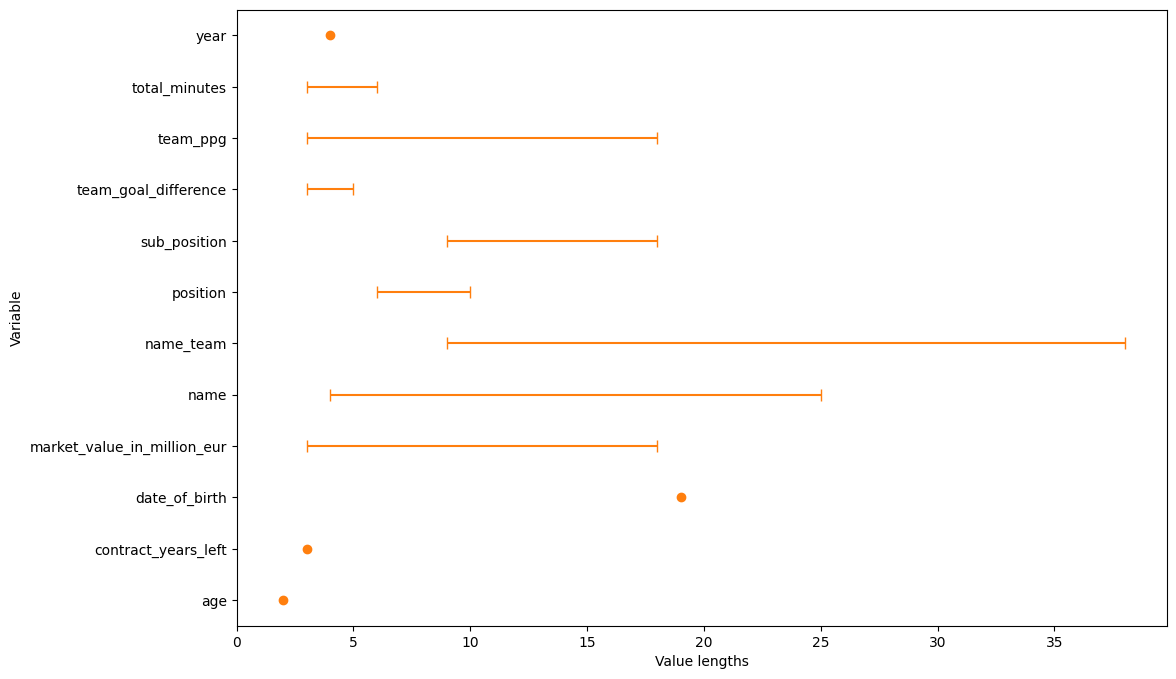

In [16]:
fig_kw = {'size_inches': (12, 8)}
ax_kw = {'xlim': 0}
vdqp.dot_whisker(df_output4['Value lengths'].sort_index(), vert=False, fig_kw=fig_kw, ax_kw=ax_kw)

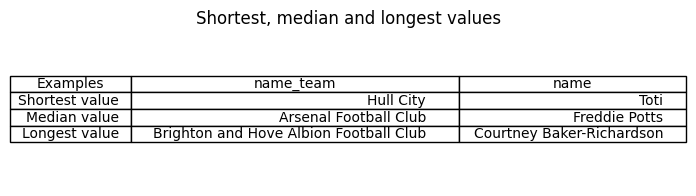

In [17]:
cols = ['name_team', 'name']
df_examples = vdqc.get_value_lengths_examples(df4[cols])
#print(df_examples)
fig_kw = {'size_inches': (4, 2)}
ax_kw = {'title': 'Shortest, median and longest values'}
vdqp.table(df_examples, include_index=False, fig_kw=fig_kw, ax_kw=ax_kw, loc='center')

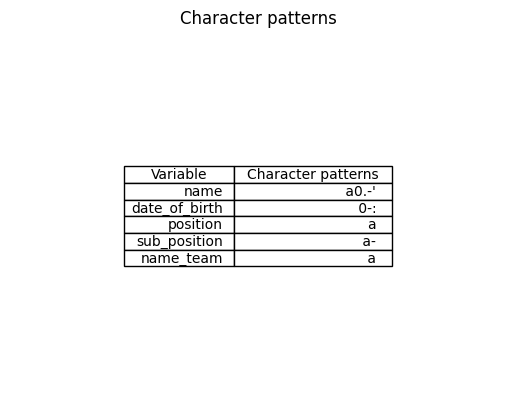

In [18]:
#print(df_output4[df_output4['Data type'] == 'object']['Character patterns'])
ax_kw = {'title': 'Character patterns'}
vdqp.table(df_output4[df_output4['Data type'] == 'object']['Character patterns'], include_index=True, ax_kw=ax_kw, loc='center')

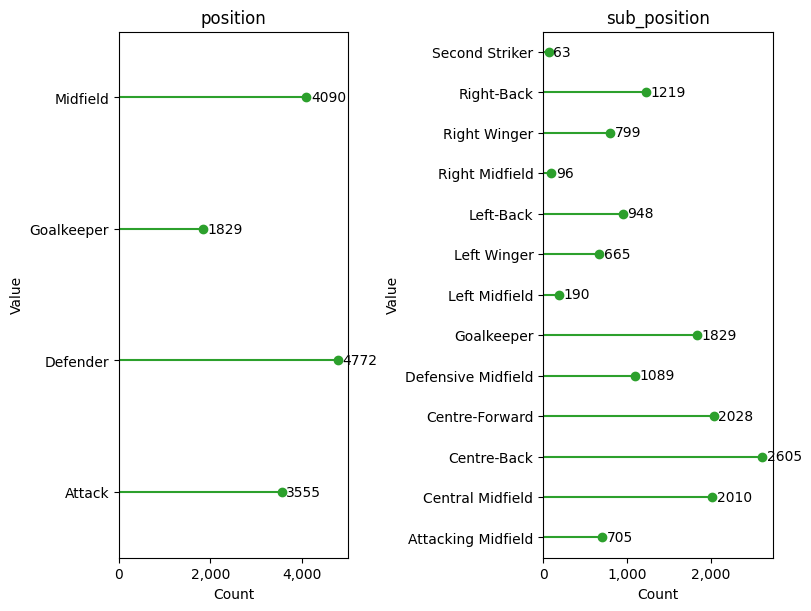

In [19]:
# Choose a threshold for plotting a variable's value counts
variables = df_output4[df_output4['Number of unique values'] <= 19].index.tolist()
variables.sort()


fig_kw = {'size_inches': (8, 6), 'constrained_layout': True}
ax_kw = {'xlim': 0, 'title': variables}
vdqp.plotgrid('value counts', df4[variables], num_cols=2, vert=False, datalabels=True, fig_kw=fig_kw, ax_kw=ax_kw)

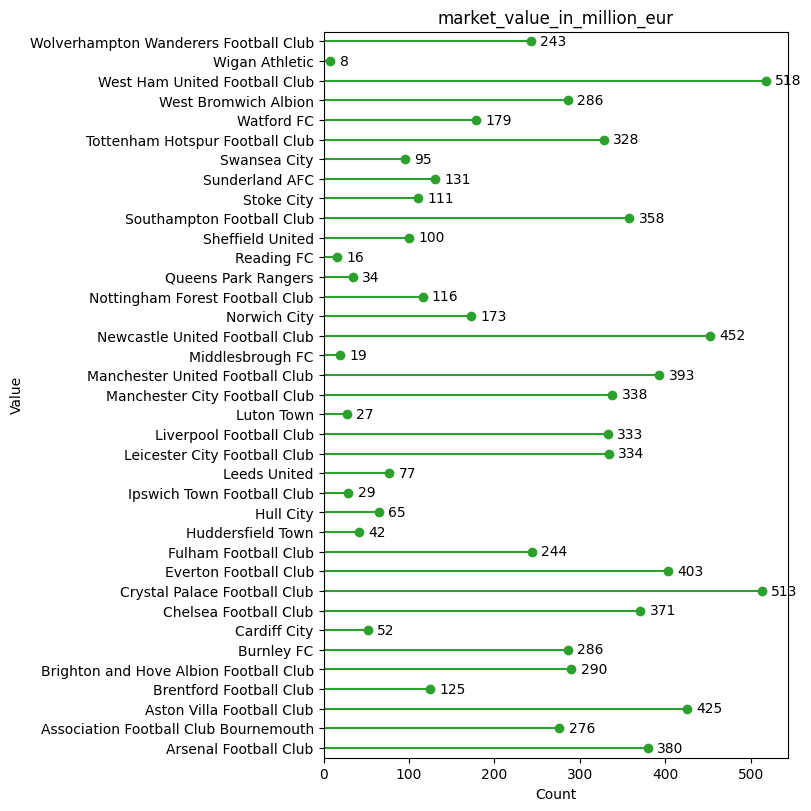

In [20]:
fig_kw = {'size_inches': (8, 8), 'constrained_layout': True}
ax_kw = {'xlim': 0, 'title': col}
col = 'name_team'
vdqp.lollipop(df4[col].value_counts(), vert=False, datalabels=True, fig_kw=fig_kw, ax_kw=ax_kw)

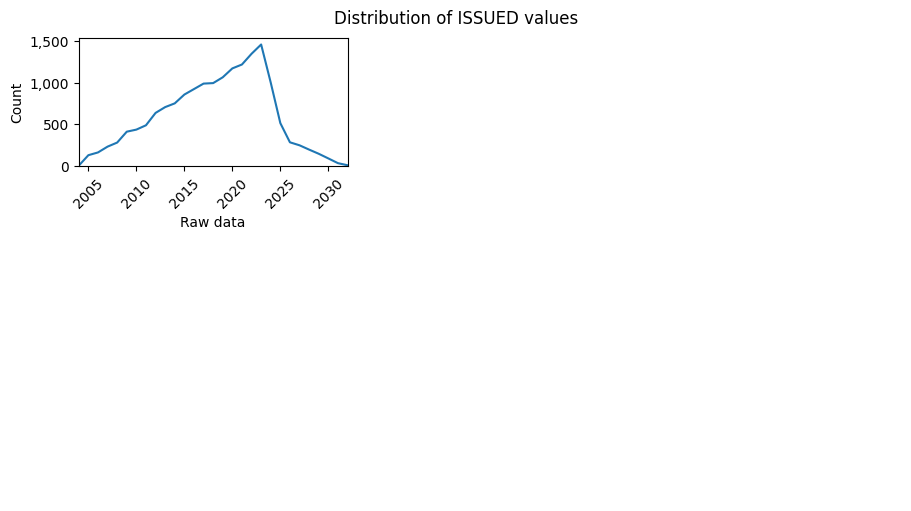

In [21]:
fig_kw = {'size_inches': (9, 5), 'constrained_layout': True}
ax_kw = {'title': 'Distribution of ISSUED values'}
components = ['raw data']
xrot = [45, 0, 90, 0, 0, 0, 0]
vdqp.plotgrid('datetime distribution', df4['year'], num_rows=3, num_cols=3, xlabels_rotate=xrot, fig_kw=fig_kw, ax_kw=ax_kw, components=components)

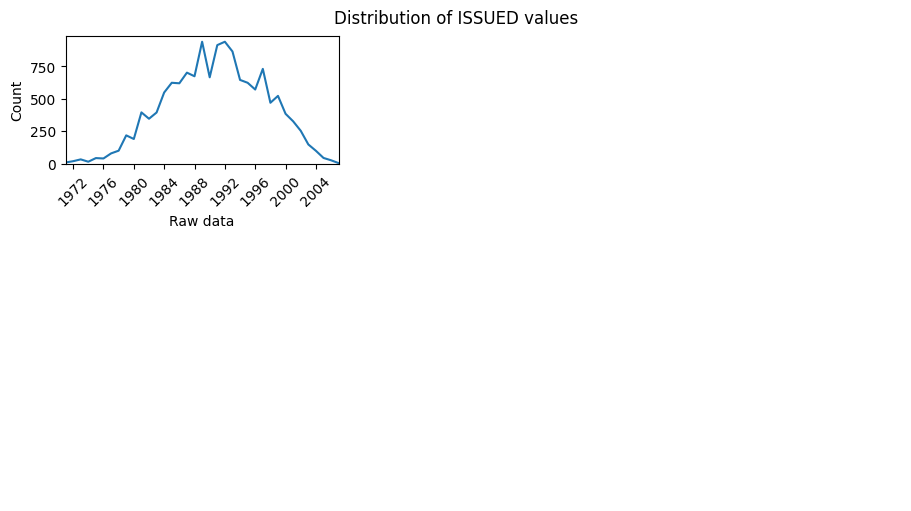

In [22]:
fig_kw = {'size_inches': (9, 5), 'constrained_layout': True}
ax_kw = {'title': 'Distribution of ISSUED values'}
components = ['raw data']
xrot = [45, 0, 90, 0, 0, 0, 0]
vdqp.plotgrid('datetime distribution', df4['date_of_birth'], num_rows=3, num_cols=3, xlabels_rotate=xrot, fig_kw=fig_kw, ax_kw=ax_kw, components=components)

In [23]:
df5 = df4.copy()

In [24]:
df_output5 = vdqc.calc(df5)

In [25]:
df_output5 

,Data type,Example value,Number of values,Number of zero values,Number of missing values,Number of unique values,Value lengths,Character patterns,Numeric percentiles,Datetime percentiles,Uniqueness,Data type conflict
_column,,,,,,,,,,,,
name,object,Danny Ward,16755,0,0,1826,"4,25",a0.-',,,Other,OK
year,int64,2023,16755,0,0,29,"4,4",,"2004.0,2014.0,2019.0,2022.0,2032.0",,Other,OK
date_of_birth,object,1989-09-26 00:00:00,14246,0,2509,1639,"19,19",0-:,,,Other,OK
market_value_in_million_eur,float64,1.0,16755,0,0,480,"3,18",,"0.002373046875,0.421875,1.5,5.2,180.0",,Other,OK
age,int64,22,16755,0,0,28,"2,2",,"16.0,22.0,26.0,32.0,43.0",,Other,OK
position,object,Defender,14246,0,2509,4,"6,10",a,,,Other,OK
sub_position,object,Centre-Back,14246,0,2509,13,"9,18",a-,,,Other,OK
contract_years_left,float64,0.0,14246,5650,2509,31,"3,3",,"0.0,0.0,3.0,6.0,6.0",,Other,OK
name_team,object,West Ham United Football Club,8170,0,8585,37,"9,38",a,,,Other,OK
